In [2]:
from types import SimpleNamespace

CFG = SimpleNamespace(
    # --- Data ---
    # Auto-detected below, but you can hard-code if needed:
    input_root   = None,          # e.g. "/kaggle/input/snapshot-wi-oh-deer"
    csv_path     = None,          # auto-globbed if None
    photos_dir   = None,          # auto-globbed if None

    # --- Model ---
    model_name   = "efficientnet_b0",   # any timm model; try "convnext_nano" for +accuracy
    img_size     = 224,
    bbox_pad     = 0.15,          # expand the bounding box by 15% before cropping
    use_bbox     = True,          # crop to the deer using the provided box

    # --- Training ---
    epochs       = 12,
    batch_size   = 8,
    lr           = 3e-4,
    weight_decay = 1e-4,
    warmup_frac  = 0.1,
    label_smooth = 0.05,
    val_frac     = 0.15,
    n_folds      = 5,             # set >1 to run stratified K-fold CV
    seed         = 42,
    num_workers  = 0,
    amp          = True,          # mixed precision (fast on T4)

    # --- Inference ---
    tune_thresholds = True,       # search decision thresholds to maximize macro-F1
    tta          = False,         # horizontal-flip TTA (small accuracy gain, 2x slower)

    # --- Output ---
    out_dir      =r"D:\电子教材\UWM\Snapshot\outputs",
    model_file   = "oh_deer_model.pt",
    pred_file    = "predictions.csv",
)
print(CFG)

namespace(input_root=None, csv_path=None, photos_dir=None, model_name='efficientnet_b0', img_size=224, bbox_pad=0.15, use_bbox=True, epochs=12, batch_size=8, lr=0.0003, weight_decay=0.0001, warmup_frac=0.1, label_smooth=0.05, val_frac=0.15, n_folds=5, seed=42, num_workers=0, amp=True, tune_thresholds=True, tta=False, out_dir='D:\\电子教材\\UWM\\Snapshot\\outputs', model_file='oh_deer_model.pt', pred_file='predictions.csv')


In [3]:
import sys, subprocess
def _pip(pkg):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

_pip("timm")

import os, glob, random, time, math, warnings
import numpy as np
import pandas as pd
from PIL import Image
Image.MAX_IMAGE_PIXELS = None
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
seed_everything(CFG.seed)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} | timm {timm.__version__} | device: {DEVICE}")
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

d:\电子教材\UWM\Snapshot\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.7.1+cu118 | timm 1.0.30 | device: cuda
GPU: NVIDIA GeForce GTX 1650


In [ ]:
# # ---- Locate the input files (robust to Kaggle's folder layout) ----
# if CFG.input_root is None:
#     candidates = glob.glob("/kaggle/input/*")
#     CFG.input_root = candidates[0] if candidates else "."
# if CFG.csv_path is None:
#     csvs = read.csv("/snapshot-wi-oh-deer/Snapshot_WI-Oh_Deer_data-v2.csv")
#     #csvs = glob.glob(os.path.join(CFG.input_root, "**", "Snapshot_WI-Oh_Deer_data-v2.csv"), recursive=True)
#     CFG.csv_path = csvs[0] if csvs else None
# if CFG.photos_dir is None:
#     # the folder that actually contains .jpg files
#     jpgs = glob.glob(os.path.join(CFG.input_root, "**", "*.jpg"), recursive=True)
#     CFG.photos_dir = os.path.dirname(jpgs[0]) if jpgs else CFG.input_root

# print("input_root:", CFG.input_root)
# print("csv_path  :", CFG.csv_path)
# print("photos_dir:", CFG.photos_dir, f"({len(glob.glob(os.path.join(CFG.photos_dir, '*.jpg')))} jpgs)")

# df = pd.read_csv(CFG.csv_path)
# print("\nCSV shape:", df.shape)
# print("Columns  :", list(df.columns))
# df.head()

input_root: /kaggle/input/competitions
csv_path  : /kaggle/input/competitions/snapshot-wi-oh-deer/Snapshot_WI-Oh_Deer_locs-v2.csv
photos_dir: /kaggle/input/competitions/snapshot-wi-oh-deer/Snapshot_WI-Oh_Deer_Photos/Deer (4880 jpgs)

CSV shape: (698, 4)
Columns  : ['camera_location_seq_no', 'dnr_grid_id', 'll_lat_dd_centroid_amt', 'll_long_dd_centroid_amt']


,camera_location_seq_no,dnr_grid_id,ll_lat_dd_centroid_amt,ll_long_dd_centroid_amt
0,48642,ELKBR001,44.371268,-90.695564
1,43445,ELKBR002,44.371478,-90.675040
2,8686,ELKBR003,44.371769,-90.654611
3,41962,ELKBR005,44.371636,-90.614087
4,41942,ELKBR005,44.371636,-90.614087


In [4]:
from pathlib import Path
import pandas as pd

CFG.input_root = r"D:\电子教材\UWM\Snapshot"

CFG.csv_path = str(
    Path(CFG.input_root) / "Snapshot_WI-Oh_Deer_data-v1.csv"
)

CFG.photos_dir = str(
    Path(CFG.input_root) / "Snapshot_WI-Oh_Deer_Photos" / "Deer"
)

# Verify the specified files exist.
if not Path(CFG.csv_path).is_file():
    raise FileNotFoundError(f"CSV not found: {CFG.csv_path}")

if not Path(CFG.photos_dir).is_dir():
    raise FileNotFoundError(f"Photos folder not found: {CFG.photos_dir}")

print("input_root:", CFG.input_root)
print("csv_path  :", CFG.csv_path)
print("photos_dir:", CFG.photos_dir)

df = pd.read_csv(CFG.csv_path)

print("\nCSV shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

input_root: D:\电子教材\UWM\Snapshot
csv_path  : D:\电子教材\UWM\Snapshot\Snapshot_WI-Oh_Deer_data-v1.csv
photos_dir: D:\电子教材\UWM\Snapshot\Snapshot_WI-Oh_Deer_Photos\Deer

CSV shape: (4880, 10)
Columns: ['filename', 'year', 'month', 'bbox_origin_x', 'bbox_origin_y', 'bbox_width', 'bbox_height', 'bbox_confidence', 'antler_status', 'age_status']


,filename,year,month,bbox_origin_x,bbox_origin_y,bbox_width,bbox_height,bbox_confidence,antler_status,age_status
0,SSWI000000027884533B.jpg,2022,6,0.2687,0.1066,0.5043,0.6933,0.966,ANTLERLESS,YOUNG
1,SSWI000000019469717A.jpg,2020,9,0.4831,0.2608,0.5168,0.7275,0.978,ANTLERLESS,YOUNG
2,SSWI000000020749648B.jpg,2021,1,0.0000,0.4750,0.6606,0.5216,0.978,ANTLERLESS,YOUNG
3,SSWI000000010695719B.jpg,2018,8,0.2587,0.4591,0.1531,0.3833,0.969,ANTLERLESS,YOUNG
4,SSWI000000020110273C.jpg,2020,8,0.2068,0.7733,0.2693,0.2241,0.956,ANTLERLESS,YOUNG


In [5]:
# ---- Fuzzy-detect the columns we need ----
import re
def find_col(df, keywords, exclude=()):
    "Pick the column best matching the *earliest* (most specific) keyword.\n"
    "Short keywords (<=2 chars like 'x','w','h') match whole tokens only, so\n"
    "'h' does NOT match inside 'width'. Longer keywords match as substrings."
    def tokens(c): return set(t for t in re.split(r"[^a-z0-9]+", c.lower()) if t)
    best, best_rank = None, 1 << 30
    for c in df.columns:
        lc = c.lower()
        if any(x in lc for x in exclude):
            continue
        t = tokens(c)
        for rank, k in enumerate(keywords):
            hit = (k in t) if len(k) <= 2 else (k in lc or k in t)
            if hit and rank < best_rank:
                best, best_rank = c, rank
                break
    return best

COLS = {
    "image":   find_col(df, ["file", "image", "photo", "img", "name", "filename"]),
    "antler":  find_col(df, ["antler"]),
    # exclude image-ish words so 'age' doesn't match inside 'image_name'
    "age":     find_col(df, ["age", "young", "adult"], exclude=["image", "img"]),
    # bounding box: try both (x,y,w,h) and (xmin,ymin,xmax,ymax) conventions
    "x":       find_col(df, ["xmin", "x_min", "left", "bbox_x", "x"], exclude=["max", "flex"]),
    "y":       find_col(df, ["ymin", "y_min", "top", "bbox_y", "y"], exclude=["max"]),
    "w":       find_col(df, ["width", "w", "bbox_w"], exclude=[]),
    "h":       find_col(df, ["height", "h", "bbox_h"], exclude=[]),
    "xmax":    find_col(df, ["xmax", "x_max", "right"]),
    "ymax":    find_col(df, ["ymax", "y_max", "bottom"]),
}
print("Detected columns:")
for k, v in COLS.items():
    print(f"  {k:8s} -> {v}")

print("\n⚠️  If any label/image column is wrong, override COLS above before continuing.")
print("    e.g. COLS['antler'] = 'AntlerStatus'")

Detected columns:
  image    -> filename
  antler   -> antler_status
  age      -> age_status
  x        -> bbox_origin_x
  y        -> bbox_origin_y
  w        -> bbox_width
  h        -> bbox_height
  xmax     -> None
  ymax     -> None

⚠️  If any label/image column is wrong, override COLS above before continuing.
    e.g. COLS['antler'] = 'AntlerStatus'


In [6]:
def normalize_label(series, positive_keys, negative_keys):
    "Map a messy text/numeric column to {0,1} using keyword lists."
    s = series.astype(str).str.strip().str.lower()
    out = pd.Series(index=s.index, dtype="float")
    for i, v in s.items():
        if any(k in v for k in positive_keys):
            out[i] = 1.0
        elif any(k in v for k in negative_keys):
            out[i] = 0.0
        else:
            out[i] = np.nan
    return out

# Class 1 = the "interesting"/rarer class in each task
df["y_antler"] = normalize_label(df[COLS["antler"]], ["antlered", "yes", "1", "true", "buck"], ["antlerless", "no", "0", "false", "doe"])
df["y_age"]    = normalize_label(df[COLS["age"]],    ["young", "fawn", "juvenile", "1"],        ["adult", "mature", "0"])

print("Antlers  (1=Antlered):")
print(df["y_antler"].value_counts(dropna=False), "\n")
print("Age      (1=Young):")
print(df["y_age"].value_counts(dropna=False))

n_bad = df["y_antler"].isna().sum() + df["y_age"].isna().sum()
if n_bad:
    print(f"\n⚠️  {n_bad} label cells couldn't be mapped — inspect the raw values below and "
          f"adjust the keyword lists in normalize_label().")
    print("Raw Antlers values:", df[COLS['antler']].astype(str).str.lower().value_counts().head(10).to_dict())
    print("Raw Age values     :", df[COLS['age']].astype(str).str.lower().value_counts().head(10).to_dict())

Antlers  (1=Antlered):
y_antler
0.0    3416
1.0    1464
Name: count, dtype: int64 

Age      (1=Young):
y_age
0.0    3904
1.0     976
Name: count, dtype: int64


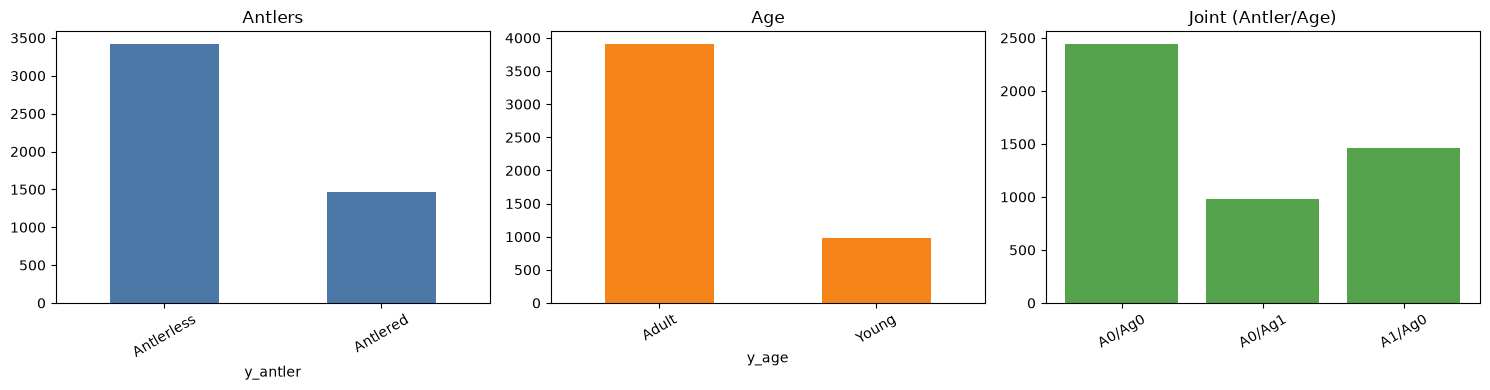


Estimated night (IR) fraction in a 200-image sample: 57%


In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
df["y_antler"].map({0:"Antlerless",1:"Antlered"}).value_counts().plot.bar(ax=ax[0], color="#4C78A8", title="Antlers")
df["y_age"].map({0:"Adult",1:"Young"}).value_counts().plot.bar(ax=ax[1], color="#F58518", title="Age")
# joint distribution
joint = df.groupby(["y_antler","y_age"]).size().rename("n").reset_index()
ax[2].bar([f"A{int(a)}/Ag{int(g)}" for a,g in zip(joint.y_antler, joint.y_age)], joint.n, color="#54A24B")
ax[2].set_title("Joint (Antler/Age)")
for a in ax: a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

# Quick day/night probe on a sample (color saturation ~ 0 for IR night shots)
def is_night(path, thresh=12):
    try:
        im = np.asarray(Image.open(path).convert("RGB").resize((64,64)), dtype=np.float32)
        sat = (im.max(-1) - im.min(-1)).mean()   # mean chroma
        return sat < thresh
    except Exception:
        return None

sample = df[COLS["image"]].dropna().sample(min(200, len(df)), random_state=0)
def resolve(fn): return fn if os.path.isabs(str(fn)) else os.path.join(CFG.photos_dir, str(fn))
night_frac = np.mean([is_night(resolve(f)) for f in sample])
print(f"\nEstimated night (IR) fraction in a 200-image sample: {night_frac:.0%}")

In [38]:
import math
import torch
import torchvision.transforms as T
from PIL import Image
from torch.utils.data import Dataset

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_bbox(row, W, H):
    "Return (left, top, right, bottom) in pixels, or None if unavailable."
    c = COLS
    try:
        if c["x"] and c["y"] and c["w"] and c["h"] and c["xmax"] is None:
            x, y, w, h = [float(row[c[k]]) for k in ("x", "y", "w", "h")]
            l, t, r, b = x, y, x + w, y + h
        elif c["x"] and c["y"] and c["xmax"] and c["ymax"]:
            l, t, r, b = [float(row[c[k]]) for k in ("x", "y", "xmax", "ymax")]
        else:
            return None

        if not all(math.isfinite(v) for v in (l, t, r, b)):
            return None
        if max(abs(l), abs(t), abs(r), abs(b)) <= 1.5:
            l, r = l * W, r * W
            t, b = t * H, b * H
        l, r = max(0, l), min(W, r)
        t, b = max(0, t), min(H, b)
        if not (r > l and b > t):
            return None
        return l, t, r, b
    except (ValueError, TypeError, KeyError):
        return None

def crop_to_bbox(img, box, pad):
    W, H = img.size
    l, t, r, b = box
    pw, ph = (r - l) * pad, (b - t) * pad
    l, t = max(0, l - pw), max(0, t - ph)
    r, b = min(W, r + pw), min(H, b + ph)
    crop_box = (int(l), int(t), max(int(r), int(l) + 1), max(int(b), int(t) + 1))
    return img.crop(crop_box)

class DeerDataset(Dataset):
    def __init__(self, frame, train=False):
        self.df = frame.reset_index(drop=True)
        self.train = train
        if train:
            aug = [
                T.Resize((CFG.img_size, CFG.img_size)),
                T.ColorJitter(
                    brightness=(1.1, 1.35),
                    contrast=(0.65, 0.9),
                    saturation=(0.0, 0.5),
                    hue=0.01,
                ),
                T.RandomApply(
                    [T.GaussianBlur(kernel_size=11, sigma=(1.0, 4.0))],
                    p=0.3,
                ),
            ]
        else:
            aug = [T.Resize((CFG.img_size, CFG.img_size))]
        self.tf = T.Compose(aug + [T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        path = resolve(row[COLS["image"]])
        try:
            img = Image.open(path).convert("RGB")
        except (OSError, ValueError):
            img = Image.new("RGB", (CFG.img_size, CFG.img_size))
        if CFG.use_bbox:
            box = get_bbox(row, *img.size)
            if box is not None:
                img = crop_to_bbox(img, box, CFG.bbox_pad)
        x = self.tf(img)
        try:
            ya = torch.tensor(int(row["y_antler"]), dtype=torch.long)
            yg = torch.tensor(int(row["y_age"]), dtype=torch.long)
        except (KeyError, TypeError, ValueError):
            raise ValueError("Labels y_antler and y_age must be valid 0/1 values") from None
        return x, ya, yg

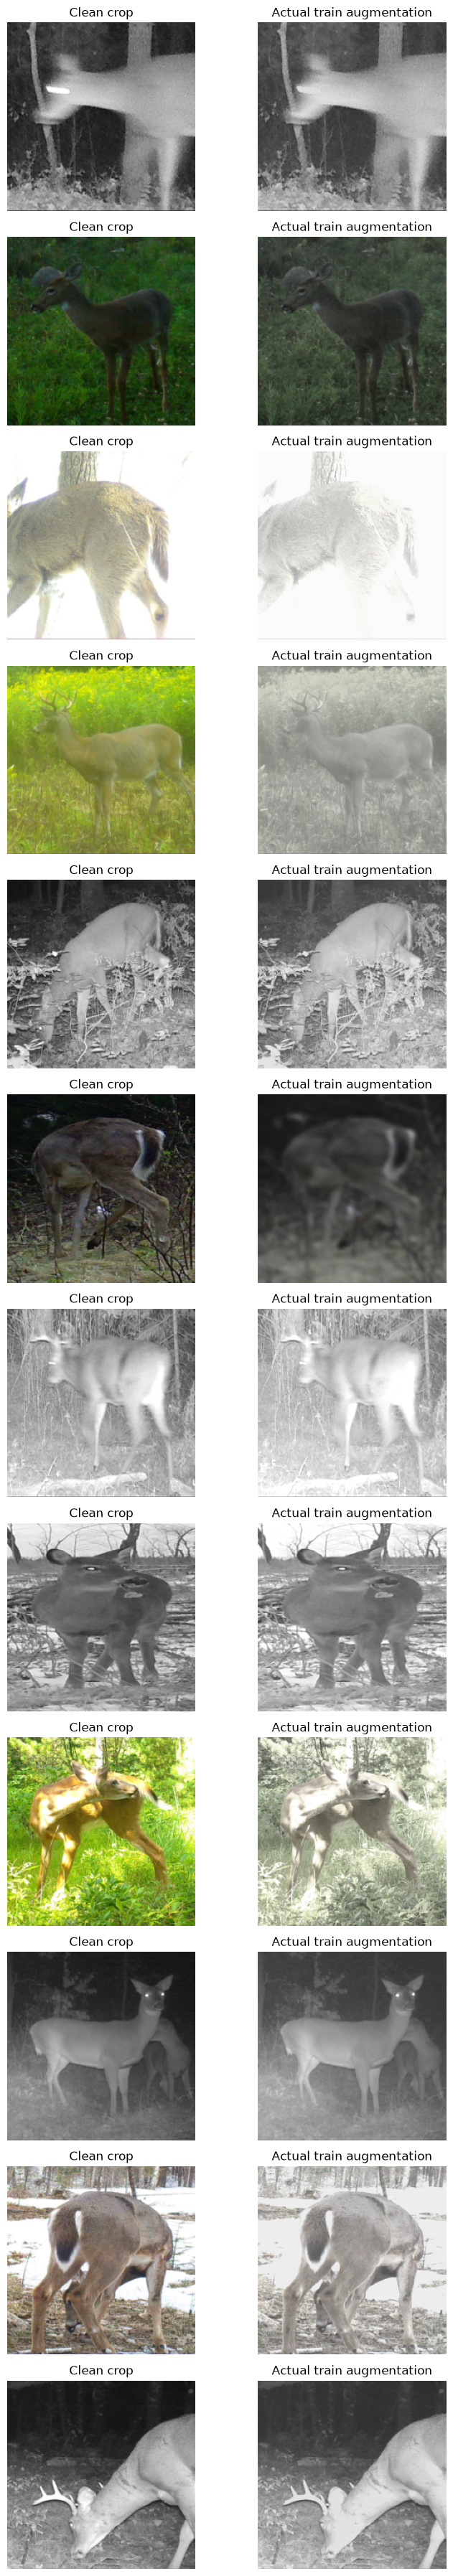

Displayed augmentation samples only; no model training was started.


In [39]:
import matplotlib.pyplot as plt

# Visual validation only: compare clean crops with actual train-time transforms.
preview_frame = df.dropna(subset=["y_antler", "y_age"]).sample(
    min(12, len(df)), random_state=CFG.seed
).reset_index(drop=True)
preview_frame["y_antler"] = preview_frame["y_antler"].astype(int)
preview_frame["y_age"] = preview_frame["y_age"].astype(int)

clean_ds = DeerDataset(preview_frame, train=False)
aug_ds = DeerDataset(preview_frame, train=True)
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def show_tensor_image(tensor):
    image = (tensor.cpu() * std + mean).clamp(0, 1)
    return image.permute(1, 2, 0).numpy()

fig, axes = plt.subplots(len(preview_frame), 2, figsize=(8, 3 * len(preview_frame)))
for i in range(len(preview_frame)):
    axes[i, 0].imshow(show_tensor_image(clean_ds[i][0]))
    axes[i, 0].set_title("Clean crop")
    axes[i, 1].imshow(show_tensor_image(aug_ds[i][0]))
    axes[i, 1].set_title("Actual train augmentation")
    axes[i, 0].axis("off")
    axes[i, 1].axis("off")
plt.tight_layout()
plt.show()
print("Displayed augmentation samples only; no model training was started.")

In [42]:
from pathlib import Path

# Regenerate 200 augmented images from the original photos.
# Do not use blur_preview here, otherwise blur would be applied twice.
augmented_dir = Path(CFG.out_dir) / "augmented_200"
augmented_dir.mkdir(parents=True, exist_ok=True)
blur_sample = df.sample(min(200, len(df)), random_state=CFG.seed).reset_index(drop=True)

export_tf = T.Compose([
    T.Resize((CFG.img_size, CFG.img_size)),
    T.ColorJitter(
        brightness=(1.1, 1.35),
        contrast=(0.65, 0.9),
        saturation=(0.0, 0.5),
        hue=0.01,
    ),
    T.RandomApply(
        [T.GaussianBlur(kernel_size=11, sigma=(1.0, 4.0))],
        p=0.3,
    ),
])

augmented_frame = blur_sample.copy().reset_index(drop=True)
augmented_frame["source_filename"] = augmented_frame[COLS["image"]].astype(str).values
augmented_paths = []
for i, row in augmented_frame.iterrows():
    source_path = Path(resolve(row["source_filename"]))
    output_path = augmented_dir / f"aug_{i:04d}_{source_path.name}"
    try:
        image = Image.open(source_path).convert("RGB")
        export_tf(image).save(output_path, quality=95)
        augmented_paths.append(str(output_path))
    except (OSError, ValueError) as exc:
        print(f"Skipped {source_path}: {exc}")
        augmented_paths.append(None)

augmented_frame[COLS["image"]] = augmented_paths
augmented_frame = augmented_frame.dropna(subset=[COLS["image"]]).reset_index(drop=True)
manifest_path = augmented_dir / "augmented_200_manifest.csv"
augmented_frame.to_csv(manifest_path, index=False)

print(f"Saved {len(augmented_frame)} augmented images to: {augmented_dir}")
print(f"Saved labels, bbox metadata, and source filenames to: {manifest_path}")
print("No model training was started.")

Saved 200 augmented images to: D:\电子教材\UWM\Snapshot\outputs\augmented_200
Saved labels, bbox metadata, and source filenames to: D:\电子教材\UWM\Snapshot\outputs\augmented_200\augmented_200_manifest.csv
No model training was started.


In [13]:
import torch.nn as nn
import timm

class MultiTaskDeer(nn.Module):
    def __init__(self, backbone=CFG.model_name, n_antler=2, n_age=2, drop=0.3):
        super().__init__()
        self.backbone = timm.create_model(backbone, pretrained=True, num_classes=0, global_pool="avg")
        feat = self.backbone.num_features
        self.drop = nn.Dropout(drop)
        self.head_antler = nn.Linear(feat, n_antler)
        self.head_age    = nn.Linear(feat, n_age)

    def forward(self, x):
        f = self.drop(self.backbone(x))
        return self.head_antler(f), self.head_age(f)

_m = MultiTaskDeer()
n_params = sum(p.numel() for p in _m.parameters()) / 1e6
print(f"{CFG.model_name}: {n_params:.1f}M parameters")
del _m

efficientnet_b0: 4.0M parameters


In [43]:
from tqdm.auto import tqdm
from torch.utils.data import ConcatDataset


def make_loaders(tr, va):
    if isinstance(tr, tuple):
        tr_original, tr_augmented = tr
        train_ds = ConcatDataset([
            DeerDataset(tr_original, train=True),
            DeerDataset(tr_augmented, train=False),
        ])
    else:
        train_ds = DeerDataset(tr, train=True)
    dl_tr = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                       num_workers=CFG.num_workers, pin_memory=True, drop_last=True)
    dl_va = DataLoader(DeerDataset(va, train=False), batch_size=CFG.batch_size*2, shuffle=False,
                       num_workers=CFG.num_workers, pin_memory=True)
    return dl_tr, dl_va

def class_weights(y):
    vals, counts = np.unique(y, return_counts=True)
    w = counts.sum() / (len(vals) * counts)
    out = torch.ones(2)
    for v, wi in zip(vals, w): out[int(v)] = wi
    return out.float().to(DEVICE)

@torch.no_grad()
def evaluate(model, dl):
    model.eval()
    pa, pg, ta, tg = [], [], [], []
    proba_a, proba_g = [], []
    for x, ya, yg in dl:
        x = x.to(DEVICE, non_blocking=True)
        with torch.autocast(DEVICE, enabled=CFG.amp):
            la, lg = model(x)
        proba_a.append(la.softmax(1)[:,1].float().cpu().numpy())
        proba_g.append(lg.softmax(1)[:,1].float().cpu().numpy())
        ta.append(ya.numpy()); tg.append(yg.numpy())
    proba_a = np.concatenate(proba_a); proba_g = np.concatenate(proba_g)
    ta = np.concatenate(ta); tg = np.concatenate(tg)
    fa = f1_score(ta, (proba_a>0.5).astype(int), average="macro")
    fg = f1_score(tg, (proba_g>0.5).astype(int), average="macro")
    return (fa+fg)/2, fa, fg, (proba_a, proba_g, ta, tg)

def train_one(tr, va, tag="model"):
    dl_tr, dl_va = make_loaders(tr, va)
    train_frame = pd.concat(tr, ignore_index=True) if isinstance(tr, tuple) else tr
    model = MultiTaskDeer().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
    steps = len(dl_tr) * CFG.epochs
    warm = int(steps * CFG.warmup_frac)
    sched = torch.optim.lr_scheduler.LambdaLR(
        opt, lambda s: s/max(1,warm) if s < warm else 0.5*(1+math.cos(math.pi*(s-warm)/max(1,steps-warm))))
    scaler = torch.cuda.amp.GradScaler(enabled=CFG.amp)
    w_a = class_weights(train_frame["y_antler"].values); w_g = class_weights(train_frame["y_age"].values)
    ce_a = nn.CrossEntropyLoss(weight=w_a, label_smoothing=CFG.label_smooth)
    ce_g = nn.CrossEntropyLoss(weight=w_g, label_smoothing=CFG.label_smooth)

    best, best_state = -1, None
    for ep in range(CFG.epochs):
        model.train(); t0 = time.time(); running = 0.0
        print(f"Starting epoch {ep+1}/{CFG.epochs} ...", flush=True)
        progress = tqdm(dl_tr, total=len(dl_tr), desc=f"Epoch {ep+1}/{CFG.epochs}", unit="batch", leave=True)
        for batch_idx, (x, ya, yg) in enumerate(progress, 1):
            x, ya, yg = x.to(DEVICE, non_blocking=True), ya.to(DEVICE, non_blocking=True), yg.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(DEVICE, enabled=CFG.amp):
                la, lg = model(x)
                loss = ce_a(la, ya) + ce_g(lg, yg)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
            running += loss.item()
            if batch_idx % 25 == 0 or batch_idx == 1:
                progress.set_postfix(loss=f"{loss.item():.3f}", avg=f"{running/batch_idx:.3f}")
        mf1, fa, fg, _ = evaluate(model, dl_va)
        print(f"[{tag}] epoch {ep+1:02d}/{CFG.epochs}  loss {running/len(dl_tr):.3f}  "
              f"macroF1 {mf1:.4f} (antler {fa:.3f} | age {fg:.3f})  {time.time()-t0:.0f}s", flush=True)
        if mf1 > best:
            best, best_state = mf1, {k: v.cpu().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    print(f"[{tag}] best val macro-F1: {best:.4f}", flush=True)
    return model

# Drop unparseable labels, then split before adding augmented copies.
data = df.dropna(subset=["y_antler", "y_age"]).reset_index(drop=True)
data["y_antler"] = data["y_antler"].astype(int); data["y_age"] = data["y_age"].astype(int)
data["_strat"] = data["y_antler"].astype(str) + data["y_age"].astype(str)
print(f"Training on {len(data)} labelled images "
      f"({len(df)-len(data)} dropped for unparseable labels)")

tr, va = train_test_split(data, test_size=CFG.val_frac, random_state=CFG.seed, stratify=data["_strat"])
if "augmented_frame" not in globals():
    raise RuntimeError("Run the augmented_200 generation cell before training.")

train_names = set(tr[COLS["image"]].astype(str))
aug_train = augmented_frame[augmented_frame["source_filename"].isin(train_names)].copy()
aug_train["y_antler"] = aug_train["y_antler"].astype(int)
aug_train["y_age"] = aug_train["y_age"].astype(int)
aug_train["_strat"] = aug_train["y_antler"].astype(str) + aug_train["y_age"].astype(str)
aug_train = aug_train[tr.columns]
print(f"Original train images: {len(tr)} | added saved augmented images: {len(aug_train)} | validation: {len(va)}")

model = train_one((tr, aug_train), va, tag="main")

Training on 4880 labelled images (0 dropped for unparseable labels)
Original train images: 4148 | added saved augmented images: 174 | validation: 732
Starting epoch 1/12 ...


Epoch 1/12: 100%|██████████| 540/540 [10:32<00:00,  1.17s/batch, avg=1.247, loss=1.083]


[main] epoch 01/12  loss 1.244  macroF1 0.7599 (antler 0.716 | age 0.804)  681s
Starting epoch 2/12 ...


Epoch 2/12: 100%|██████████| 540/540 [10:08<00:00,  1.13s/batch, avg=1.073, loss=0.859]


[main] epoch 02/12  loss 1.071  macroF1 0.7698 (antler 0.752 | age 0.788)  648s
Starting epoch 3/12 ...


...

[main] epoch 10/12  loss 0.439  macroF1 0.8392 (antler 0.810 | age 0.868)  661s
Starting epoch 11/12 ...


Epoch 11/12: 100%|██████████| 540/540 [09:58<00:00,  1.11s/batch, avg=0.425, loss=0.259]


[main] epoch 11/12  loss 0.424  macroF1 0.8312 (antler 0.812 | age 0.850)  640s
Starting epoch 12/12 ...


Epoch 12/12: 100%|██████████| 540/540 [10:33<00:00,  1.17s/batch, avg=0.415, loss=0.297]


[main] epoch 12/12  loss 0.415  macroF1 0.8305 (antler 0.808 | age 0.853)  678s
[main] best val macro-F1: 0.8392


In [44]:
mf1, fa, fg, (pa, pg, ta, tg) = evaluate(model, make_loaders(tr, va)[1])

def best_threshold(proba, y):
    grid = np.linspace(0.1, 0.9, 81)
    scores = [f1_score(y, (proba>t).astype(int), average="macro") for t in grid]
    j = int(np.argmax(scores)); return float(grid[j]), float(scores[j])

if CFG.tune_thresholds:
    th_a, f_a = best_threshold(pa, ta)
    th_g, f_g = best_threshold(pg, tg)
else:
    th_a, th_g = 0.5, 0.5
    f_a = f1_score(ta, (pa>0.5).astype(int), average="macro")
    f_g = f1_score(tg, (pg>0.5).astype(int), average="macro")

CFG.threshold_antler, CFG.threshold_age = th_a, th_g
print(f"Antlers  threshold={th_a:.2f}  macro-F1={f_a:.4f}")
print(f"Age      threshold={th_g:.2f}  macro-F1={f_g:.4f}")
print(f"\n>>> Combined leaderboard proxy (mean macro-F1): {(f_a+f_g)/2:.4f}"
      f"  ->  ~{(f_a+f_g)/2*100:.1f} / 100 points\n")

print("=== Antlers ===")
print(classification_report(ta, (pa>th_a).astype(int), target_names=["Antlerless","Antlered"], digits=3))
print("=== Age ===")
print(classification_report(tg, (pg>th_g).astype(int), target_names=["Adult","Young"], digits=3))

Antlers  threshold=0.70  macro-F1=0.8374
Age      threshold=0.80  macro-F1=0.8838

>>> Combined leaderboard proxy (mean macro-F1): 0.8606  ->  ~86.1 / 100 points

=== Antlers ===
              precision    recall  f1-score   support

  Antlerless      0.884     0.936     0.909       512
    Antlered      0.826     0.714     0.766       220

    accuracy                          0.869       732
   macro avg      0.855     0.825     0.837       732
weighted avg      0.866     0.869     0.866       732

=== Age ===
              precision    recall  f1-score   support

       Adult      0.935     0.983     0.958       586
       Young      0.914     0.726     0.809       146

    accuracy                          0.932       732
   macro avg      0.924     0.854     0.884       732
weighted avg      0.931     0.932     0.929       732



In [49]:
def day_night(path, thresh=12):
    try:
        im = np.asarray(Image.open(path).convert("RGB").resize((64,64)), dtype=np.float32)
        sat = float((im.max(-1) - im.min(-1)).mean())
        return ("Night" if sat < thresh else "Day"), sat
    except Exception:
        return ("Unknown", np.nan)

def proximity(row):
    "Bbox area as a fraction of the frame -> Close / Mid / Far."
    try:
        img = Image.open(resolve(row[COLS["image"]]))
        box = get_bbox(row, *img.size)
        if not box: return ("Unknown", np.nan)
        l,t,r,b = box; frac = ((r-l)*(b-t)) / (img.size[0]*img.size[1])
        lvl = "Close" if frac > 0.25 else ("Mid" if frac > 0.06 else "Far")
        return (lvl, round(float(frac),4))
    except Exception:
        return ("Unknown", np.nan)

# demo on a few rows
for _, r in data.sample(5, random_state=1).iterrows():
    dn, sat = day_night(resolve(r[COLS["image"]]))
    px, frac = proximity(r)
    print(f"{str(r[COLS['image']])[:40]:40s}  {dn:5s} (sat {sat:5.1f})  {px:6s} (area {frac})")

SSWI000000024756490A.jpg                  Night (sat   0.0)  Mid    (area 0.0917)
SSWI000000030363079A.jpg                  Night (sat   0.0)  Far    (area 0.0357)
SSWI000000011393920C.jpg                  Day   (sat  24.1)  Mid    (area 0.0953)
SSWI000000016082572C.jpg                  Night (sat   0.0)  Mid    (area 0.1797)
SSWI000000015087594A.jpg                  Night (sat   0.0)  Far    (area 0.0355)


In [ ]:
@torch.no_grad()
def predict_frame(frame, with_bonus=True):
    ds = DeerDataset(frame.assign(y_antler=0, y_age=0), train=False)
    dl = DataLoader(ds, batch_size=CFG.batch_size*2, shuffle=False, num_workers=CFG.num_workers)
    model.eval(); pa, pg = [], []
    t0 = time.time()
    for x, _, _ in dl:
        x = x.to(DEVICE, non_blocking=True)
        with torch.autocast(DEVICE, enabled=CFG.amp):
            la, lg = model(x)
            if CFG.tta:
                la2, lg2 = model(torch.flip(x, dims=[3]))
                la = (la.softmax(1)+la2.softmax(1))/2; lg = (lg.softmax(1)+lg2.softmax(1))/2
            else:
                la, lg = la.softmax(1), lg.softmax(1)
        pa.append(la[:,1].float().cpu().numpy()); pg.append(lg[:,1].float().cpu().numpy())
    dt = time.time()-t0
    pa = np.concatenate(pa); pg = np.concatenate(pg)
    print(f"Inference: {len(frame)} images in {dt:.1f}s  ->  {len(frame)/dt:.1f} images/sec "
          f"({DEVICE}, {CFG.model_name}, fp16={CFG.amp})")

    out = pd.DataFrame({COLS["image"]: frame[COLS["image"]].values})
    out["Antlers"] = np.where(pa > CFG.threshold_antler, "Antlered", "Antlerless")
    out["Age"]     = np.where(pg > CFG.threshold_age, "Young", "Adult")
    out["antler_prob"] = pa.round(4); out["age_prob"] = pg.round(4)
    if with_bonus:
        dn = [day_night(resolve(f)) for f in frame[COLS["image"]]]
        out["time_of_day"] = [d[0] for d in dn]
        px = [proximity(r) for _, r in frame.iterrows()]
        out["proximity"] = [p[0] for p in px]
        out["bbox_area_frac"] = [p[1] for p in px]
    return out

preds = predict_frame(data)
preds.to_csv(os.path.join(CFG.out_dir, CFG.pred_file), index=False)
print("Saved:", os.path.join(CFG.out_dir, CFG.pred_file))
preds.head(10)

Inference: 4880 images in 267.1s  ->  18.3 images/sec (cuda, efficientnet_b0, fp16=True)
Saved: D:\电子教材\UWM\Snapshot\outputs\predictions.csv


,filename,Antlers,Age,antler_prob,age_prob,time_of_day,proximity,bbox_area_frac
0,SSWI000000027884533B.jpg,Antlerless,Young,0.0832,0.9907,Night,Close,0.3496
1,SSWI000000019469717A.jpg,Antlerless,Young,0.0843,0.9874,Day,Close,0.3760
2,SSWI000000020749648B.jpg,Antlerless,Young,0.0627,0.9089,Night,Close,0.3446
3,SSWI000000010695719B.jpg,Antlerless,Young,0.0092,0.9954,Night,Far,0.0587
4,SSWI000000020110273C.jpg,Antlerless,Young,0.0216,0.9958,Day,Mid,0.0604
5,SSWI000000011340915C.jpg,Antlerless,Young,0.0413,0.9967,Day,Mid,0.0940
6,SSWI000000027884532C.jpg,Antlerless,Young,0.0965,0.9838,Night,Close,0.3318
7,SSWI000000013189074A.jpg,Antlerless,Adult,0.0458,0.6989,Day,Mid,0.1879
8,SSWI000000012449090C.jpg,Antlerless,Young,0.0163,0.9999,Night,Mid,0.0700
9,SSWI000000030689976C.jpg,Antlerless,Young,0.0142,0.9993,Night,Mid,0.1937
